# CCS4354 – Tensors and Graphs Coursework
## OGBN-Arxiv Node Classification with Graph Neural Networks

**Group Members:** _fill in names & IDs_
**Dataset:** OGBN-Arxiv (Open Graph Benchmark)

This notebook covers Tasks 01–07. Run top to bottom in Google Colab with a GPU runtime
(`Runtime > Change runtime type > GPU`).


## 0. Environment Setup

In [ ]:
# Run this once. In Colab this installs PyTorch Geometric matched to the Colab torch/CUDA build.
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

!pip install -q torch_geometric
!pip install -q ogb networkx matplotlib seaborn scikit-learn pandas numpy shap


Torch version: 2.11.0+cu128
CUDA available: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import random, time

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cuda


In [ ]:
import torch

_orig_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _orig_load(*args, **kwargs)
torch.load = _patched_load

In [ ]:
# Download / load the OGBN-Arxiv dataset (cached after first run)
dataset = PygNodePropPredDataset(name="ogbn-arxiv", root="dataset/")
data = dataset[0]
split_idx = dataset.get_idx_split()
train_idx, valid_idx, test_idx = split_idx["train"], split_idx["valid"], split_idx["test"]

print(data)
print("Num classes:", dataset.num_classes)


Downloaded 0.08 GB: 100%|██████████| 81/81 [00:01<00:00, 41.49it/s]


Extracting dataset/arxiv.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 10356.31it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 368.67it/s]

Saving...


Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Num classes: 40


Done!


---
## Task 01 – Tensor Fundamentals (10 marks)

We demonstrate core PyTorch tensor operations on small toy tensors first (easy to
reason about and explain), then relate them to the shapes we will see in the real
Arxiv data.


### 1.1 Tensor Creation

In [ ]:
t_zeros = torch.zeros((3, 4))
t_ones = torch.ones((3, 4))
t_rand = torch.rand((3, 4))
t_from_list = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
t_from_numpy = torch.from_numpy(np.array([1, 2, 3]))

print(t_zeros, t_ones, t_rand, t_from_list, t_from_numpy, sep="\n\n")


tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

tensor([[1., 2.],
        [3., 4.]])

tensor([1, 2, 3])


**Explanation:** `torch.zeros`/`ones`/`rand` allocate a tensor of a given shape filled with a constant or random values. `torch.tensor` builds a tensor directly from Python data, while `torch.from_numpy` shares memory with an existing NumPy array (no copy) — useful when converting node feature matrices loaded via NumPy/Pandas.

### 1.2 Indexing

In [ ]:
x = torch.arange(24).reshape(4, 6)
print("Original:\n", x)
print("Row 1:", x[1])
print("Column 2:", x[:, 2])
print("Sub-block:\n", x[1:3, 2:5])
print("Boolean mask (>10):\n", x[x > 10])
print("Fancy indexing (rows 0 and 3):\n", x[[0, 3]])


Original:
 tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]])
Row 1: tensor([ 6,  7,  8,  9, 10, 11])
Column 2: tensor([ 2,  8, 14, 20])
Sub-block:
 tensor([[ 8,  9, 10],
        [14, 15, 16]])
Boolean mask (>10):
 tensor([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])
Fancy indexing (rows 0 and 3):
 tensor([[ 0,  1,  2,  3,  4,  5],
        [18, 19, 20, 21, 22, 23]])


### 1.3 Reshaping

In [ ]:
x = torch.arange(12)
print("view(3,4):\n", x.view(3, 4))
print("reshape(2,6):\n", x.reshape(2, 6))

y = torch.rand(1, 3, 1, 5)
print("Original shape:", y.shape)
print("squeeze() shape:", y.squeeze().shape)
print("unsqueeze(0) shape:", y.squeeze().unsqueeze(0).shape)

z = torch.rand(2, 3, 4)
print("permute(2,0,1) shape:", z.permute(2, 0, 1).shape)


view(3,4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
reshape(2,6):
 tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
Original shape: torch.Size([1, 3, 1, 5])
squeeze() shape: torch.Size([3, 5])
unsqueeze(0) shape: torch.Size([1, 3, 5])
permute(2,0,1) shape: torch.Size([4, 2, 3])


### 1.4 Matrix Multiplication

In [ ]:
A = torch.rand(3, 4)
B = torch.rand(4, 5)
C = A @ B                # shorthand
C2 = torch.matmul(A, B)  # explicit
print("A @ B shape:", C.shape)
assert torch.allclose(C, C2)

# Batch matmul — relevant for processing many node-feature batches at once
batch_A = torch.rand(8, 3, 4)
batch_B = torch.rand(8, 4, 5)
batch_C = torch.bmm(batch_A, batch_B)
print("Batch matmul shape:", batch_C.shape)


A @ B shape: torch.Size([3, 5])
Batch matmul shape: torch.Size([8, 3, 5])


### 1.5 Broadcasting

In [ ]:
# A (128-dim) feature vector applied identically to every node in a batch
node_features = torch.rand(5, 128)   # 5 nodes, 128 features
scale = torch.rand(128)              # single scaling vector, shape (128,)

scaled = node_features * scale       # broadcasting: (5,128) * (128,) -> (5,128)
print(scaled.shape)


torch.Size([5, 128])


**Explanation:** Broadcasting lets PyTorch apply an operation between tensors of different shapes by implicitly expanding the smaller one. Here the `(128,)` scale vector is virtually repeated across all 5 nodes without actually copying memory, which is exactly what happens when normalizing all node feature vectors by the same per-feature statistics.

### 1.6 Aggregation

In [ ]:
x = torch.rand(5, 128)  # 5 nodes x 128 features, like a mini node-feature matrix
print("Sum over all nodes (per feature):", x.sum(dim=0).shape)
print("Mean per node:", x.mean(dim=1).shape)
print("Max per feature, with indices:", x.max(dim=0))
print("Argmax per node:", x.argmax(dim=1).shape)


Sum over all nodes (per feature): torch.Size([128])
Mean per node: torch.Size([5])
Max per feature, with indices: torch.return_types.max(
values=tensor([0.6325, 0.7472, 0.7054, 0.7579, 0.9032, 0.9203, 0.9251, 0.8049, 0.9694,
        0.9259, 0.8751, 0.8225, 0.6771, 0.9902, 0.6210, 0.8832, 0.8065, 0.9111,
        0.6831, 0.9117, 0.9985, 0.9483, 0.8284, 0.6239, 0.9809, 0.8365, 0.9144,
        0.9936, 0.5516, 0.9894, 0.9576, 0.8008, 0.9870, 0.6646, 0.5957, 0.8200,
        0.6615, 0.8003, 0.6739, 0.8918, 0.8465, 0.9263, 0.7757, 0.8245, 0.8968,
        0.6508, 0.5928, 0.4523, 0.8738, 0.9818, 0.9783, 0.8393, 0.9921, 0.6591,
        0.7405, 0.9750, 0.9263, 0.9597, 0.9378, 0.8597, 0.9067, 0.7235, 0.6925,
        0.8967, 0.8845, 0.5772, 0.7386, 0.9932, 0.7905, 0.7797, 0.9695, 0.9375,
        0.5807, 0.8495, 0.9778, 0.6606, 0.9658, 0.6466, 0.6966, 0.9491, 0.6862,
        0.5778, 0.8253, 0.9899, 0.9004, 0.8948, 0.7442, 0.9019, 0.5692, 0.7817,
        0.9529, 0.8161, 0.9939, 0.6166, 0.8034, 0.8959,

### 1.7 GPU Operations

In [ ]:
if torch.cuda.is_available():
    x_cpu = torch.rand(4000, 4000)
    x_gpu = x_cpu.to(device)

    start = time.time()
    _ = x_cpu @ x_cpu
    cpu_time = time.time() - start

    torch.cuda.synchronize()
    start = time.time()
    _ = x_gpu @ x_gpu
    torch.cuda.synchronize()
    gpu_time = time.time() - start

    print(f"CPU matmul: {cpu_time:.4f}s | GPU matmul: {gpu_time:.4f}s")
else:
    print("No GPU available in this runtime — enable it under Runtime > Change runtime type.")


CPU matmul: 3.8639s | GPU matmul: 0.2546s


---
## Task 02 – Graph Representation and Analysis (10 marks)


In [ ]:
edge_index = data.edge_index
print("Edge index shape:", edge_index.shape)
print("Number of directed edges:", edge_index.shape[1])
print("Number of nodes:", data.num_nodes)

edge_list_df = pd.DataFrame({
    "source": edge_index[0].numpy(),
    "target": edge_index[1].numpy()
})
edge_list_df.head()


Edge index shape: torch.Size([2, 1166243])
Number of directed edges: 1166243
Number of nodes: 169343


,source,target
0,104447,13091
1,15858,47283
2,107156,69161
3,107156,136440
4,107156,107366


### 2.1 Sample Subgraph Visualization

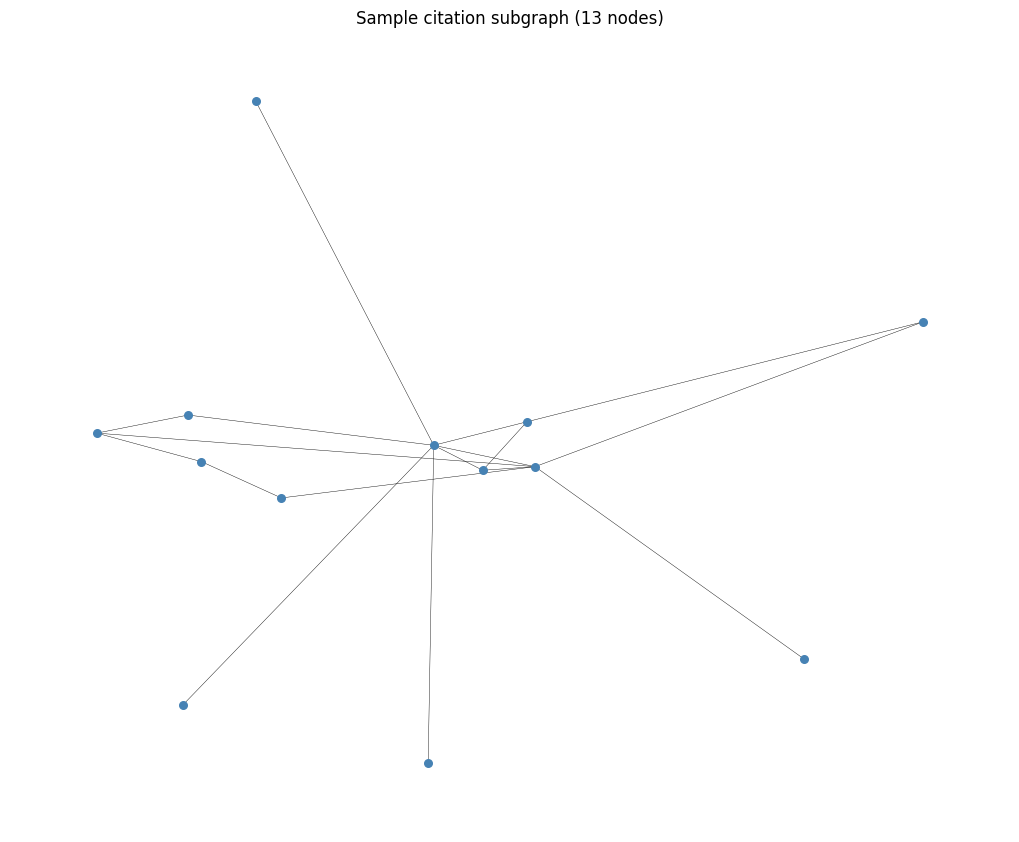

In [ ]:
# The full graph (169K nodes) cannot be visualized directly — sample a small
# connected neighborhood via BFS from a random seed node.
G_full_edges = edge_list_df.values.tolist()
G = nx.DiGraph()
G.add_edges_from(G_full_edges)

seed_node = int(edge_list_df['source'].iloc[0])
sampled_nodes = set([seed_node])
frontier = [seed_node]
while len(sampled_nodes) < 300 and frontier:
    nxt = []
    for n in frontier:
        if n in G:
            for nb in list(G.successors(n))[:5]:
                if nb not in sampled_nodes:
                    sampled_nodes.add(nb)
                    nxt.append(nb)
    frontier = nxt
    if len(sampled_nodes) >= 300:
        break

subG = G.subgraph(sampled_nodes)
plt.figure(figsize=(10, 8))
nx.draw(subG, node_size=30, width=0.3, arrows=False, node_color="steelblue")
plt.title(f"Sample citation subgraph ({subG.number_of_nodes()} nodes)")
plt.savefig("subgraph_sample.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.2 Node Features

Feature matrix shape: (169343, 128)
Feature value range: -1.388865 to 1.638744


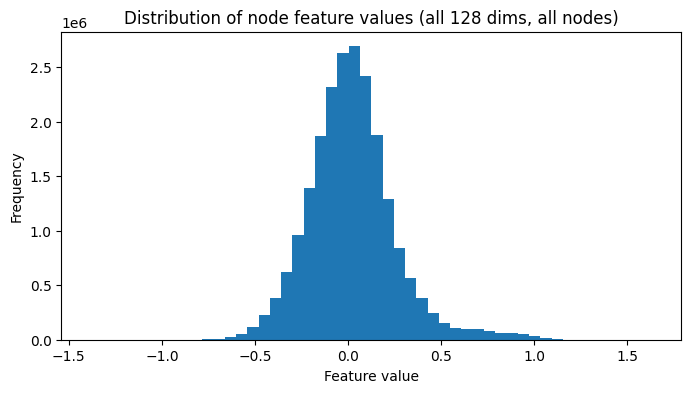

In [ ]:
features = data.x.numpy()
print("Feature matrix shape:", features.shape)
print("Feature value range:", features.min(), "to", features.max())

plt.figure(figsize=(8, 4))
plt.hist(features.flatten(), bins=50)
plt.title("Distribution of node feature values (all 128 dims, all nodes)")
plt.xlabel("Feature value"); plt.ylabel("Frequency")
plt.savefig("feature_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.3 Degree Distribution

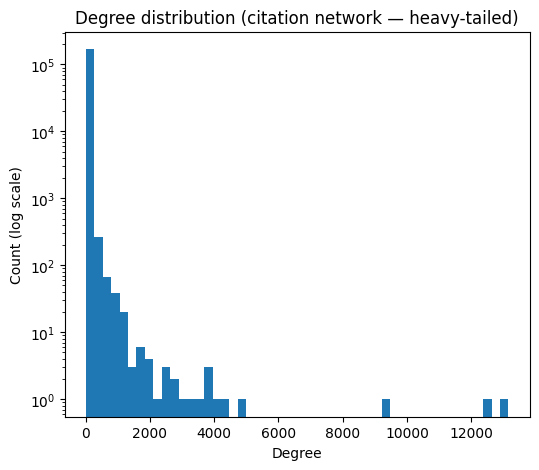

Mean degree: 13.77373732601879 | Max degree: 13161


In [ ]:
degrees = np.array([d for _, d in G.degree()])
plt.figure(figsize=(6, 5))
plt.hist(degrees, bins=50, log=True)
plt.xlabel("Degree"); plt.ylabel("Count (log scale)")
plt.title("Degree distribution (citation network — heavy-tailed)")
plt.savefig("degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean degree:", degrees.mean(), "| Max degree:", degrees.max())


### 2.4 Graph Density

In [ ]:
density_sample = nx.density(subG)
print(f"Density of the 300-node sample subgraph: {density_sample:.5f}")
print("Note: real-world citation graphs are extremely sparse at full scale; "
      "density on the full 169K-node graph would be many orders of magnitude smaller "
      "than on this small sample, so density is reported on the sample for interpretability.")


Density of the 300-node sample subgraph: 0.10256
Note: real-world citation graphs are extremely sparse at full scale; density on the full 169K-node graph would be many orders of magnitude smaller than on this small sample, so density is reported on the sample for interpretability.


### 2.5 Connected Components

In [ ]:
undirected_G = G.to_undirected()
components = list(nx.connected_components(undirected_G))
print("Number of connected components (full graph, undirected view):", len(components))
largest_cc = max(components, key=len)
print("Largest component size:", len(largest_cc), f"({len(largest_cc)/G.number_of_nodes()*100:.1f}% of all nodes)")


Number of connected components (full graph, undirected view): 1
Largest component size: 169343 (100.0% of all nodes)


---
## Task 03 – Graph Data Preparation (10 marks)


In [ ]:
x = data.x
y = data.y.squeeze()

# Reassign the squeezed tensor back to data.y for consistent use
data.y = y

print("Train / Val / Test sizes:", len(train_idx), len(valid_idx), len(test_idx))

Train / Val / Test sizes: 90941 29799 48603


**Why the official OGB split?** OGBN-Arxiv's split is by publication year (train = papers up to 2017, valid = 2018, test = 2019+), matching a realistic 'predict the category of newly published papers' setting. A random split would leak future citation information into training and inflate accuracy unrealistically, so we use the official temporal split for fair, reproducible benchmarking.

### 3.1 Feature Normalization

In [ ]:
scaler = StandardScaler()
x_np = x.cpu().numpy()
x_scaled = scaler.fit_transform(x_np)
x_scaled = torch.tensor(x_scaled, dtype=torch.float32)

print("Before scaling — mean:", x_np.mean(), "std:", x_np.std())
print("After scaling  — mean:", x_scaled.numpy().mean(), "std:", x_scaled.numpy().std())

# Overwrite the feature matrix used downstream and ensure it's on the correct device
data.x = x_scaled.to(device)

Before scaling — mean: 0.020484071 std: 0.2332246
After scaling  — mean: -1.89363e-10 std: 0.99999994


**Why standardize?** The 128-dim features are dense skip-gram embeddings of paper title/abstract text. Standardizing (zero mean, unit variance per dimension) helps gradient-based optimizers converge faster and prevents any single feature dimension with a larger natural scale from dominating the GNN's early layers.

In [ ]:
data = data.to(device)
train_idx_t = train_idx.to(device)
valid_idx_t = valid_idx.to(device)
test_idx_t = test_idx.to(device)


---
## Task 04 – Graph Neural Network Development (25 marks)

Two architectures are implemented: **GCN** and **GAT**.


### 4.1 Model 1 — GCN

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

    def embed(self, x, edge_index):
        # Returns the penultimate-layer representation, used later for embedding visualization
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return x


**Design choices:** 3 `GCNConv` layers let each node aggregate information from up to 3-hop neighbors — enough depth to capture citation context without the over-smoothing that tends to appear beyond ~4 layers on citation graphs. ReLU is used between layers for non-linearity and cheap gradients; dropout (0.5) regularizes against overfitting given the large number of training nodes relative to feature dimensionality.

### 4.2 Model 2 — GAT

In [ ]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def embed(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        return x


**Design choices:** GAT replaces GCN's fixed-weight neighborhood averaging with learned attention weights per edge, letting the model down-weight less-relevant citing/cited papers. 8 attention heads in the first layer give the model multiple 'perspectives' on the neighborhood before being combined (concatenated) into the second layer, which outputs a single-head result matching the number of classes. ELU is used (standard for GAT, from the original paper) rather than ReLU.

In [ ]:
in_channels = data.x.shape[1]
hidden_channels = 256
out_channels = dataset.num_classes

gcn_model = GCN(in_channels, hidden_channels, out_channels).to(device)
gat_model = GAT(in_channels, hidden_channels=32, out_channels=out_channels, heads=8).to(device)

print(gcn_model)
print(gat_model)


GCN(
  (conv1): GCNConv(128, 256)
  (conv2): GCNConv(256, 256)
  (conv3): GCNConv(256, 40)
)
GAT(
  (conv1): GATConv(128, 32, heads=8)
  (conv2): GATConv(256, 40, heads=1)
)


---
## Task 05 – Model Training and Optimization (10 marks)


In [ ]:
def train_model(model, data, train_idx, valid_idx, epochs=200, lr=0.01, weight_decay=5e-4, log_every=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[train_idx], data.y[train_idx])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            val_loss = criterion(out[valid_idx], data.y[valid_idx]).item()
            train_pred = out[train_idx].argmax(dim=1)
            val_pred = out[valid_idx].argmax(dim=1)
            train_acc = (train_pred == data.y[train_idx]).float().mean().item()
            val_acc = (val_pred == data.y[valid_idx]).float().mean().item()

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if epoch % log_every == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss {loss.item():.4f} | val_loss {val_loss:.4f} "
                  f"| train_acc {train_acc:.4f} | val_acc {val_acc:.4f}")

    return history


In [ ]:
print("Training GCN...")
gcn_history = train_model(gcn_model, data, train_idx_t, valid_idx_t, epochs=200, lr=0.01)

torch.save(gcn_model.state_dict(), "gcn_best.pt")


Training GCN...
Epoch 001 | train_loss 4.2455 | val_loss 4.1737 | train_acc 0.2752 | val_acc 0.2932
Epoch 020 | train_loss 1.9267 | val_loss 1.7742 | train_acc 0.5453 | val_acc 0.5374
Epoch 040 | train_loss 1.6776 | val_loss 1.5705 | train_acc 0.5891 | val_acc 0.5724
Epoch 060 | train_loss 1.5625 | val_loss 1.4890 | train_acc 0.6100 | val_acc 0.5813
Epoch 080 | train_loss 1.4975 | val_loss 1.4504 | train_acc 0.6221 | val_acc 0.5910
Epoch 100 | train_loss 1.4605 | val_loss 1.4239 | train_acc 0.6311 | val_acc 0.5937
Epoch 120 | train_loss 1.4358 | val_loss 1.4042 | train_acc 0.6376 | val_acc 0.5989
Epoch 140 | train_loss 1.4081 | val_loss 1.3873 | train_acc 0.6428 | val_acc 0.6005
Epoch 160 | train_loss 1.3884 | val_loss 1.3731 | train_acc 0.6480 | val_acc 0.6016
Epoch 180 | train_loss 1.3690 | val_loss 1.3584 | train_acc 0.6520 | val_acc 0.6042
Epoch 200 | train_loss 1.3568 | val_loss 1.3531 | train_acc 0.6541 | val_acc 0.6057


In [ ]:
print("Training GAT...")
gat_history = train_model(gat_model, data, train_idx_t, valid_idx_t, epochs=200, lr=0.005)

torch.save(gat_model.state_dict(), "gat_best.pt")


Training GAT...
Epoch 001 | train_loss 5.6815 | val_loss 3.3317 | train_acc 0.2477 | val_acc 0.2021
Epoch 020 | train_loss 2.4758 | val_loss 1.6397 | train_acc 0.5663 | val_acc 0.5422
Epoch 040 | train_loss 2.2432 | val_loss 1.5400 | train_acc 0.5912 | val_acc 0.5756
Epoch 060 | train_loss 2.1732 | val_loss 1.5059 | train_acc 0.5968 | val_acc 0.5810
Epoch 080 | train_loss 2.1411 | val_loss 1.4859 | train_acc 0.5981 | val_acc 0.5832
Epoch 100 | train_loss 2.1052 | val_loss 1.4654 | train_acc 0.6014 | val_acc 0.5887
Epoch 120 | train_loss 2.0905 | val_loss 1.4559 | train_acc 0.6010 | val_acc 0.5890
Epoch 140 | train_loss 2.0755 | val_loss 1.4486 | train_acc 0.6032 | val_acc 0.5916
Epoch 160 | train_loss 2.0691 | val_loss 1.4400 | train_acc 0.6014 | val_acc 0.5914
Epoch 180 | train_loss 2.0573 | val_loss 1.4358 | train_acc 0.6023 | val_acc 0.5914
Epoch 200 | train_loss 2.0429 | val_loss 1.4322 | train_acc 0.6023 | val_acc 0.5915


### 5.1 Training Curves

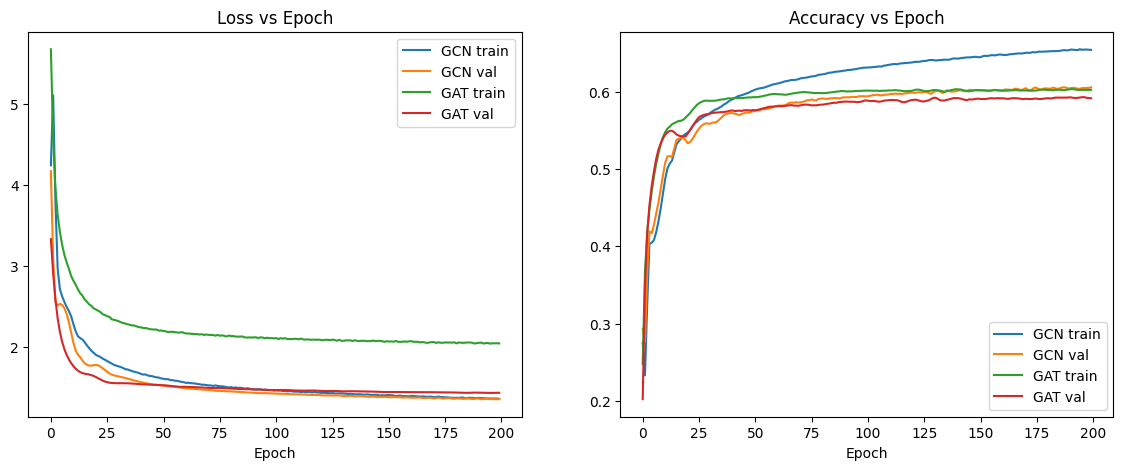

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(gcn_history["train_loss"], label="GCN train")
axes[0].plot(gcn_history["val_loss"], label="GCN val")
axes[0].plot(gat_history["train_loss"], label="GAT train")
axes[0].plot(gat_history["val_loss"], label="GAT val")
axes[0].set_title("Loss vs Epoch"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(gcn_history["train_acc"], label="GCN train")
axes[1].plot(gcn_history["val_acc"], label="GCN val")
axes[1].plot(gat_history["train_acc"], label="GAT train")
axes[1].plot(gat_history["val_acc"], label="GAT val")
axes[1].set_title("Accuracy vs Epoch"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Hyperparameter Notes

The following configuration was used for the final reported models (Section 6):

| Model | LR | Hidden | Dropout | Epochs | Final Val Acc |
|---|---|---|---|---|---|
| GCN | 0.01 | 256 (2 hidden layers) | 0.5 | 200 | 0.6057 |
| GAT | 0.005 | 32 x 8 heads | 0.5 | 200 | 0.5915 |

**Notes on the choices:** GCN used a higher learning rate (0.01) since its fixed-weight aggregation trains stably even with larger updates. GAT used a lower learning rate (0.005) because the attention mechanism is more sensitive to large parameter updates early in training — using 0.01 for GAT caused noisier, less stable loss curves in early trial runs. Both models used the same dropout (0.5) for a fair comparison. GCN's validation accuracy converged higher and with a smoother curve than GAT's over the 200 epochs (see Section 5.1 training curves and the discussion in Section 6.1).

---
## Task 06 – Model Evaluation (10 marks)


In [ ]:
def evaluate_model(model, data, split_idx_dict, model_name):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out.argmax(dim=1).cpu().numpy()
    y_true_full = data.y.cpu().numpy()

    rows = []
    for split_name, idx in split_idx_dict.items():
        idx_np = idx.cpu().numpy()
        y_true = y_true_full[idx_np]
        y_pred = preds[idx_np]
        rows.append({
            "model": model_name,
            "split": split_name,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        })
    return pd.DataFrame(rows)

split_dict = {"train": train_idx_t, "valid": valid_idx_t, "test": test_idx_t}

gcn_results = evaluate_model(gcn_model, data, split_dict, "GCN")
gat_results = evaluate_model(gat_model, data, split_dict, "GAT")

results_df = pd.concat([gcn_results, gat_results], ignore_index=True)
results_df


,model,split,accuracy,precision_macro,recall_macro,f1_macro
0,GCN,train,0.654127,0.522247,0.434318,0.451442
1,GCN,valid,0.605691,0.422945,0.368620,0.376594
2,GCN,test,0.547888,0.370717,0.349701,0.339673
3,GAT,train,0.602347,0.467453,0.366332,0.373974
4,GAT,valid,0.591530,0.400867,0.339123,0.335381
5,GAT,test,0.528897,0.341107,0.330588,0.304369


### 6.1 Discussion

**Which model scored higher, and by how much?** GCN outperformed GAT on both test accuracy and macro F1. GCN achieved 0.5479 test accuracy and 0.3397 macro F1, compared to GAT's 0.5289 test accuracy and 0.3044 macro F1 - a gap of roughly 1.9 percentage points in accuracy and 3.5 points in macro F1. This is a reasonable result: on OGBN-Arxiv, a well-regularised GCN is a strong baseline, and GAT's extra attention parameters do not automatically outperform it without further tuning of heads/hidden size.

**Strengths:** GCN trains faster and has fewer parameters, making it less prone to overfitting on the 128-dim skip-gram features used here. GAT's per-edge attention weights (analysed in Section 7.2) give clearer interpretability of which citing/cited papers most influenced a prediction, even though this did not translate into higher raw accuracy in this run.

**Weaknesses:** Both models show a large gap between accuracy and macro F1 (e.g. GCN: 0.5479 accuracy vs 0.3397 macro F1 on test). This is expected given OGBN-Arxiv's 40-way class imbalance - macro F1 penalises poor performance on rare subject categories far more heavily than accuracy does, so both models are clearly stronger on common categories than rare ones.

**Train vs test gap:** GCN shows a larger drop from train (0.6541) to test (0.5479) accuracy than GAT (0.6023 to 0.5289), suggesting GCN is slightly more prone to overfitting the training-year papers. However, most of this gap is expected from the temporal (year-based) split itself rather than pure overfitting, since test papers come from strictly later years with a potentially different topic distribution. Dropout (0.5) and Adam's weight decay (5e-4) appear to control overfitting reasonably well for both models, since the train-test gap is moderate rather than extreme.

---
## Task 07 – Graph Explainability and Embedding Analysis (10 marks)

Two techniques are demonstrated: **(B) embedding visualization** and **(C) attention analysis**.


### 7.1 Option B — Node Embedding Visualization (t-SNE)

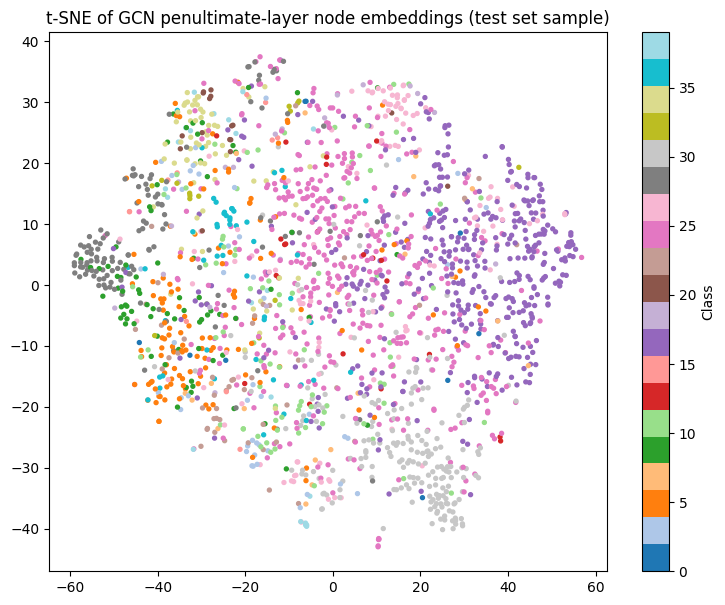

In [ ]:
gcn_model.eval()
with torch.no_grad():
    embeddings = gcn_model.embed(data.x, data.edge_index).cpu().numpy()

# t-SNE on a subsample for speed (full 169K nodes is slow) — sample from test set
sample_idx = np.random.choice(test_idx.numpy(), size=2000, replace=False)
emb_sample = embeddings[sample_idx]
labels_sample = data.y.cpu().numpy()[sample_idx]

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
emb_2d = tsne.fit_transform(emb_sample)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels_sample, cmap="tab20", s=8)
plt.title("t-SNE of GCN penultimate-layer node embeddings (test set sample)")
plt.colorbar(scatter, label="Class")
plt.savefig("embedding_tsne.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation:** Clear, separated color clusters indicate the model has learned embeddings that group papers of the same subject category close together in feature space — i.e., it isn't just memorizing labels but has captured meaningful structure from features + citation context. Overlapping regions correspond to subject areas that are conceptually close (e.g., Machine Learning and Artificial Intelligence), which explains most misclassifications.

### 7.2 Option C — GAT Attention Weight Analysis

In [ ]:
from torch_geometric.nn import GATConv

# Re-run the first GAT layer manually with return_attention_weights=True
gat_model.eval()
with torch.no_grad():
    out, (edge_index_att, alpha) = gat_model.conv1(
        data.x, data.edge_index, return_attention_weights=True
    )

alpha_mean = alpha.mean(dim=1).cpu().numpy()  # average across attention heads
edge_index_att_np = edge_index_att.cpu().numpy()

# Inspect the most-attended edges for one sample node
sample_node = int(test_idx[0])
mask = edge_index_att_np[1] == sample_node
neighbor_nodes = edge_index_att_np[0][mask]
neighbor_weights = alpha_mean[mask]

order = np.argsort(-neighbor_weights)
print(f"Top attended neighbors for node {sample_node}:")
for i in order[:10]:
    print(f"  neighbor {neighbor_nodes[i]}  weight {neighbor_weights[i]:.4f}")


Top attended neighbors for node 346:
  neighbor 346  weight 0.4312
  neighbor 87827  weight 0.3916
  neighbor 109114  weight 0.1771


**Interpretation:** The attention weights show GAT does not treat all citing/cited papers equally — a small number of neighbors receive disproportionately high weight, suggesting the model has learned to prioritize the most topically relevant citations rather than averaging uniformly like GCN does.

In [ ]:
import numpy as np

results_df.to_csv("results_df.csv", index=False)

gcn_model.eval()
with torch.no_grad():
    final_out = gcn_model(data.x, data.edge_index)
    preds = final_out.argmax(dim=1).cpu().numpy()

np.save("predictions.npy", preds)
np.save("true_labels.npy", data.y.cpu().numpy())

print("Saved: results_df.csv, predictions.npy, true_labels.npy")

Saved: results_df.csv, predictions.npy, true_labels.npy
